In [1]:
import pandas as pd 
import numpy as np


df = pd.read_csv('Telco-Customer-Churn.csv')
print(df.shape)

#df.head()

#missing_pct = (df.isna().sum() / len(df) * 100).round(2)
#print(missing_pct)

print(df['Churn'].value_counts(normalize=True))
#print(df[df['TotalCharges'] == ' '][['tenure','TotalCharges']])

df['TotalCharges'] = df['TotalCharges'].replace(' ', 0)
df['TotalCharges'] = df['TotalCharges'].astype(float)

print(df['TotalCharges'].dtype)
#print(df[df['TotalCharges'] == 0][['tenure','TotalCharges']])
#df.info()
print(df.columns)


(7043, 21)
Churn
No     0.73463
Yes    0.26537
Name: proportion, dtype: float64
float64
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [3]:
df.groupby('Contract')['Churn'].value_counts(normalize=True) 
df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True)
pd.crosstab(df['PaymentMethod'], df['Contract'], normalize='index')
df.groupby('Churn')['tenure'].mean()
df.groupby('Churn')['MonthlyCharges'].mean()
#df.groupby('Churn')['SeniorCitizen'].value_counts(normalize=True)
df['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

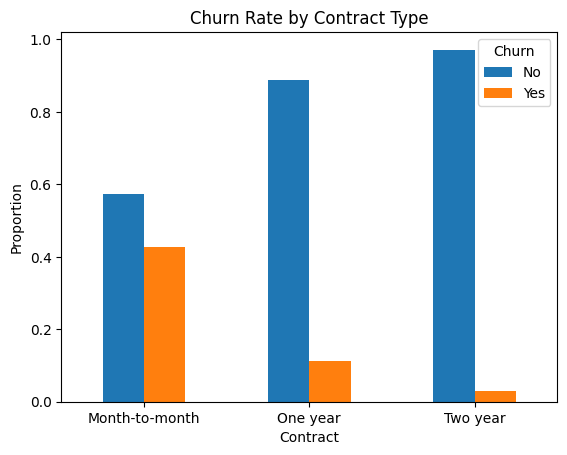

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

churn_by_contract = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack()
churn_by_contract.plot(kind='bar', stacked=False)
plt.title('Churn Rate by Contract Type')
plt.xticks(rotation = 0)
plt.ylabel('Proportion')
plt.show()

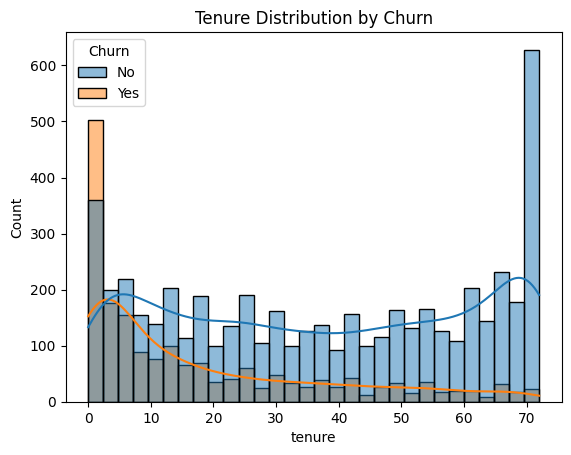

In [5]:
sns.histplot(data=df, x='tenure', hue='Churn', bins=30, kde=True)
plt.title('Tenure Distribution by Churn')
plt.show()

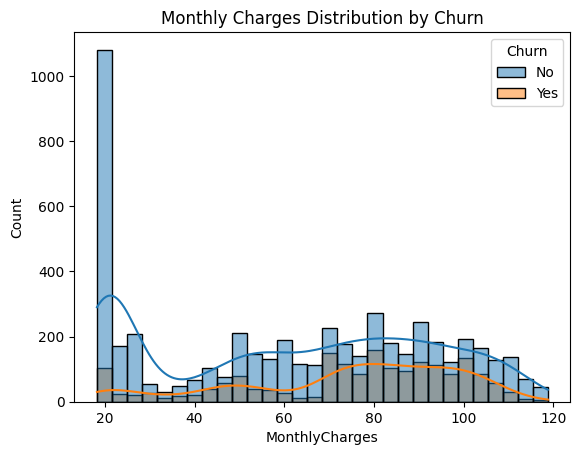

In [6]:
sns.histplot(data=df, x='MonthlyCharges', hue='Churn', bins=30, kde=True)
plt.title('Monthly Charges Distribution by Churn')
plt.show()

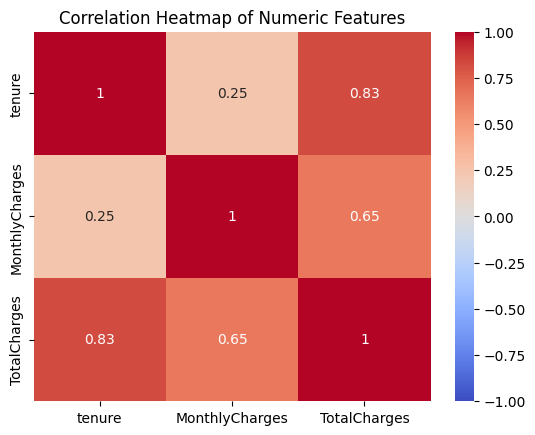

In [7]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

In [8]:
df.groupby('InternetService')['Churn'].value_counts(normalize=True)
#df.groupby('InternetService')['MonthlyCharges'].mean()
pd.crosstab(df['InternetService'], df['Contract'], normalize='index')
df['OnlineSecurity'].value_counts()
df['TechSupport'].value_counts()
#df.groupby('TechSupport')['Churn'].value_counts(normalize=True)
#pd.crosstab(df['TechSupport'], df['Contract'], normalize='index')

TechSupport
No                     3473
Yes                    2044
No internet service    1526
Name: count, dtype: int64

In [9]:
df.select_dtypes(include='object').columns
len(df.select_dtypes(include='object').columns)

# for col in ['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 
#             'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 
#             'StreamingMovies', 'PaymentMethod', 'Contract']:
#     print(col, ':', df[col].unique())
#df.dtypes

C:\Users\HP\AppData\Local\Temp\ipykernel_3068\3283095304.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns
C:\Users\HP\AppData\Local\Temp\ipykernel_3068\3283095304.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.

17

In [10]:
#label encoding for binary categorical variables
binary_cols = ['Partner', 'Dependents', 'PaperlessBilling', 'PhoneService', 'Churn']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Female': 1, 'Male': 0})

#one-hot encoding for categorical variables with more than two categories
multi_cat_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
                   'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
                   'Contract', 'PaymentMethod']

df = pd.get_dummies(df, columns=multi_cat_cols)

In [11]:
df.shape
#df.dtypes
df.dtypes.value_counts()
#len(df.columns)

bool       31
int64       8
float64     2
str         1
Name: count, dtype: int64

In [12]:
df = df.drop(columns=['customerID', 'TotalCharges'])

In [13]:
X = df.drop(columns=['Churn'])
y = df['Churn']

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score


X_train, X_test, y_train, y_test = train_test_split(X,
      y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(5634, 39)
(1409, 39)
Churn
0    0.734647
1    0.265353
Name: proportion, dtype: float64
Churn
0    0.734564
1    0.265436
Name: proportion, dtype: float64


In [14]:
lr_model = LogisticRegression(class_weight='balanced',
                               random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

y_pred = lr_model.predict(X_test)

print(classification_report(y_test, y_pred))
print('ROC-AUC Score:', roc_auc_score(y_test,
                     lr_model.predict_proba(X_test)[:, 1]))




              precision    recall  f1-score   support

           0       0.90      0.73      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409

ROC-AUC Score: 0.8384613397401123


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))
print('ROC-AUC Score:', roc_auc_score(y_test, 
                        rf_model.predict_proba(X_test)[:, 1]))

              precision    recall  f1-score   support

           0       0.82      0.88      0.85      1035
           1       0.60      0.48      0.53       374

    accuracy                           0.78      1409
   macro avg       0.71      0.68      0.69      1409
weighted avg       0.76      0.78      0.77      1409

ROC-AUC Score: 0.8140380789997158


In [16]:
from xgboost import XGBClassifier

negative = (y_train == 0).sum()
positive = (y_train == 1).sum()
scale = negative / positive
print(scale)

xgb_model = XGBClassifier(scale_pos_weight=scale, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC Score:', roc_auc_score(y_test, xgb_model.predict_proba(X_test)[:, 1]))

2.768561872909699
              precision    recall  f1-score   support

           0       0.86      0.78      0.82      1035
           1       0.52      0.65      0.57       374

    accuracy                           0.75      1409
   macro avg       0.69      0.71      0.70      1409
weighted avg       0.77      0.75      0.75      1409

ROC-AUC Score: 0.815404686248676


In [17]:
import joblib

# Save the model
joblib.dump(lr_model, 'churn_model.pkl')

# Save the feature column names
import json
with open('feature_columns.json', 'w') as f:
    json.dump(list(X_train.columns), f)

print('Model and feature columns saved successfully')

Model and feature columns saved successfully


In [18]:
# Verify it loads back correctly
loaded_model = joblib.load('churn_model.pkl')
test_pred = loaded_model.predict(X_test)
print('Model loads and predicts correctly:', test_pred[:5])

Model loads and predicts correctly: [0 1 0 1 0]
